<a href="https://colab.research.google.com/github/antoshdyade/Blockchain-XAI-Transformer/blob/main/ThesisImpV2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install torch torchvision torchaudio
!pip install torch-geometric
!pip install pandas numpy matplotlib seaborn scikit-learn
!pip install networkx tqdm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 79.0 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import networkx as nx

import torch
import torch.nn.functional as F

from torch_geometric.data import Data
from torch_geometric.nn import GCNConv,GATConv,SAGEConv

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import IsolationForest

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping

import matplotlib.pyplot as plt
import seaborn as sns

from tqdm import tqdm

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
BASE_PATH = "/content/drive/MyDrive/Elliptic"

FEATURE_FILE = f"{BASE_PATH}/elliptic_txs_features.csv"
CLASS_FILE   = f"{BASE_PATH}/elliptic_txs_classes.csv"
EDGE_FILE    = f"{BASE_PATH}/elliptic_txs_edgelist.csv"

In [5]:
features = pd.read_csv(FEATURE_FILE, header=None)

classes = pd.read_csv(CLASS_FILE)

edges = pd.read_csv(EDGE_FILE)

print(features.shape)
print(classes.shape)
print(edges.shape)

(203769, 167)
(203769, 2)
(234355, 2)


In [6]:
feature_cols = ["txId"] + [f"f{i}" for i in range(166)]

features.columns = feature_cols

features.head()

,txId,f0,f1,f2,f3,f4,f5,f6,f7,f8,...,f156,f157,f158,f159,f160,f161,f162,f163,f164,f165
0,230425980,1,-0.171469,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162097,...,-0.562153,-0.600999,1.461330,1.461369,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792
1,5530458,1,-0.171484,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162112,...,0.947382,0.673103,-0.979074,-0.978556,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792
2,232022460,1,-0.172107,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162749,...,0.670883,0.439728,-0.979074,-0.978556,-0.098889,-0.106715,-0.131155,-0.183671,-0.120613,-0.119792
3,232438397,1,0.163054,1.963790,-0.646376,12.409294,-0.063725,9.782742,12.414558,-0.163645,...,-0.577099,-0.613614,0.241128,0.241406,1.072793,0.085530,-0.131155,0.677799,-0.120613,-0.119792
4,230460314,1,1.011523,-0.081127,-1.201369,1.153668,0.333276,1.312656,-0.061584,-0.163523,...,-0.511871,-0.400422,0.517257,0.579382,0.018279,0.277775,0.326394,1.293750,0.178136,0.179117


In [7]:
data = features.merge(classes,on="txId")

data.head()

,txId,f0,f1,f2,f3,f4,f5,f6,f7,f8,...,f157,f158,f159,f160,f161,f162,f163,f164,f165,class
0,230425980,1,-0.171469,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162097,...,-0.600999,1.461330,1.461369,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792,unknown
1,5530458,1,-0.171484,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162112,...,0.673103,-0.979074,-0.978556,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792,unknown
2,232022460,1,-0.172107,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162749,...,0.439728,-0.979074,-0.978556,-0.098889,-0.106715,-0.131155,-0.183671,-0.120613,-0.119792,unknown
3,232438397,1,0.163054,1.963790,-0.646376,12.409294,-0.063725,9.782742,12.414558,-0.163645,...,-0.613614,0.241128,0.241406,1.072793,0.085530,-0.131155,0.677799,-0.120613,-0.119792,2
4,230460314,1,1.011523,-0.081127,-1.201369,1.153668,0.333276,1.312656,-0.061584,-0.163523,...,-0.400422,0.517257,0.579382,0.018279,0.277775,0.326394,1.293750,0.178136,0.179117,unknown


In [8]:
data['class'] = data['class'].replace({
    '1':1,
    '2':0,
    'unknown':-1
})

data = data[data['class']!=-1]

print(data['class'].value_counts())

class
0    42019
1     4545
Name: count, dtype: int64


/tmp/ipykernel_4251/2789658036.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data['class'] = data['class'].replace({


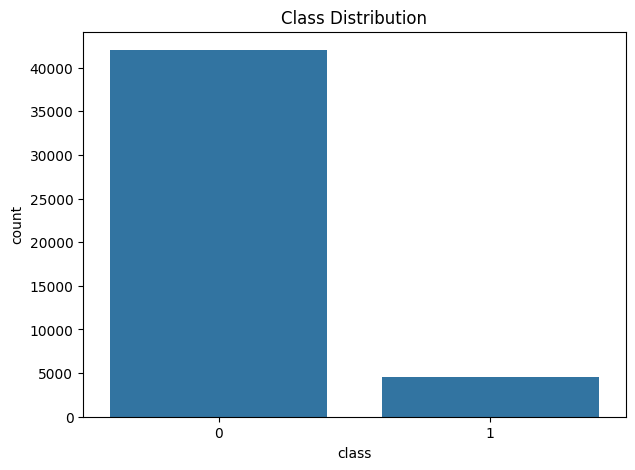

In [9]:
plt.figure(figsize=(7,5))

sns.countplot(x=data['class'])

plt.title("Class Distribution")
plt.show()

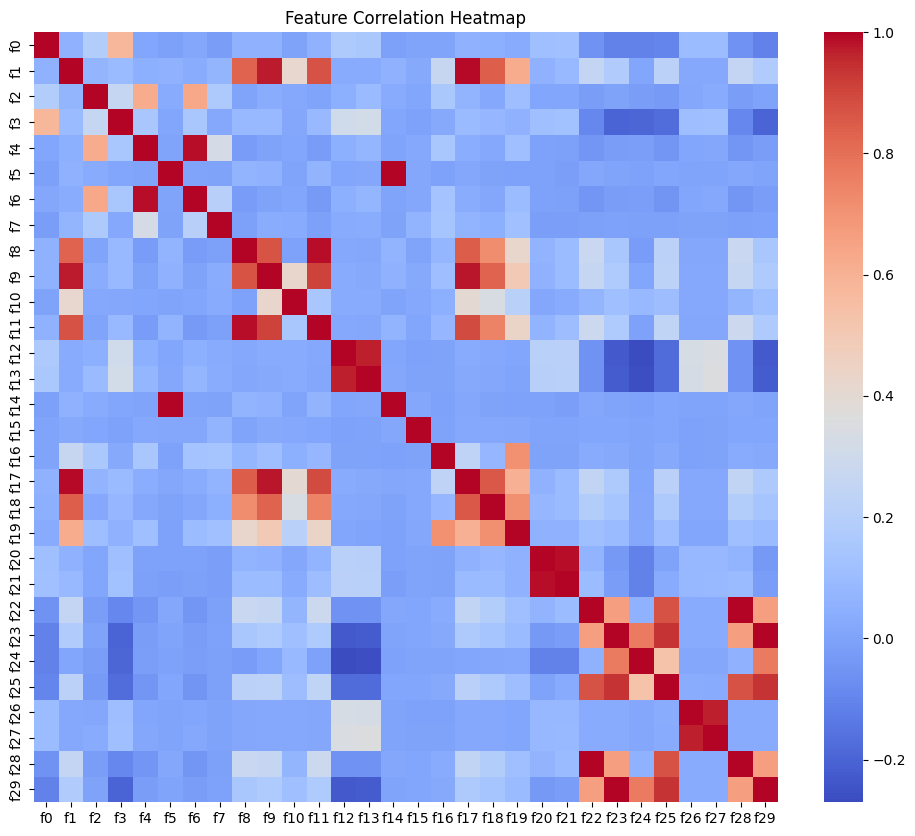

In [10]:
corr = data.iloc[:,1:31].corr()

plt.figure(figsize=(12,10))

sns.heatmap(corr,cmap='coolwarm')

plt.title("Feature Correlation Heatmap")

plt.show()

In [11]:
corr_target = data.corr(numeric_only=True)['class'].abs()

top10 = corr_target.sort_values(
    ascending=False
).head(11)

top10

,class
class,1.000000
f53,0.261472
f89,0.227629
f55,0.227146
f90,0.221294
f142,0.191936
f150,0.187232
f91,0.185804
f52,0.171799
f154,0.152966


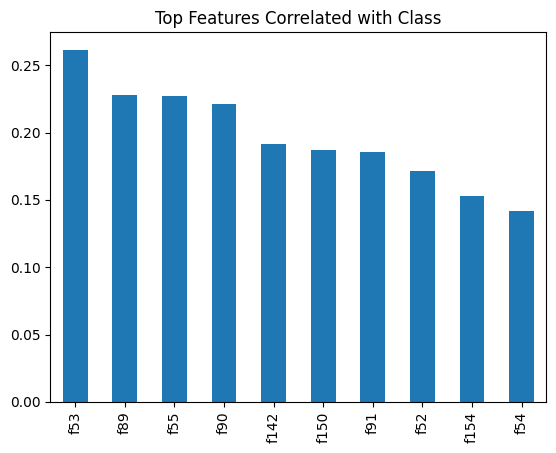

In [12]:
top10[1:].plot(kind='bar')

plt.title("Top Features Correlated with Class")

plt.show()

In [13]:
node_ids = data['txId'].values

X = data.drop(columns=['txId','class']).values

y = data['class'].values

In [14]:
scaler = StandardScaler()

X = scaler.fit_transform(X)

In [15]:
node_map = {
    node:i
    for i,node in enumerate(node_ids)
}

In [16]:
edge_index=[]

for _,row in tqdm(edges.iterrows(),total=len(edges)):

    s=row['txId1']
    d=row['txId2']

    if s in node_map and d in node_map:

        edge_index.append([
            node_map[s],
            node_map[d]
        ])

edge_index=np.array(edge_index)

100%|██████████| 234355/234355 [00:06<00:00, 35894.11it/s]


In [17]:
x=torch.tensor(X,dtype=torch.float)

y=torch.tensor(y,dtype=torch.long)

edge_index=torch.tensor(
    edge_index.T,
    dtype=torch.long
)

graph_data = Data(
    x=x,
    edge_index=edge_index,
    y=y
)

graph_data

Data(x=[46564, 166], edge_index=[2, 36624], y=[46564])

In [18]:
idx=np.arange(len(y))

train_idx,test_idx=train_test_split(
    idx,
    test_size=0.2,
    stratify=y,
    random_state=42
)

train_mask=torch.zeros(len(y),dtype=torch.bool)
test_mask=torch.zeros(len(y),dtype=torch.bool)

train_mask[train_idx]=True
test_mask[test_idx]=True

graph_data.train_mask=train_mask
graph_data.test_mask=test_mask

In [19]:
import numpy as np
import pandas as pd

results=[]

def evaluate_model(
        model,
        data,
        model_name):

    model.eval()

    with torch.no_grad():

        logits=model(data.x,data.edge_index)

        probs=F.softmax(logits,dim=1)

        pred=probs.argmax(dim=1)

    y_true=data.y[data.test_mask].cpu().numpy()

    y_pred=pred[data.test_mask].cpu().numpy()

    y_prob=probs[data.test_mask][:,1].cpu().numpy()

    acc=accuracy_score(y_true,y_pred)

    prec=precision_score(
        y_true,
        y_pred,
        zero_division=0
    )

    rec=recall_score(
        y_true,
        y_pred,
        zero_division=0
    )

    f1=f1_score(
        y_true,
        y_pred,
        zero_division=0
    )

    roc=roc_auc_score(
        y_true,
        y_prob
    )

    pr=average_precision_score(
        y_true,
        y_prob
    )

    results.append([
        model_name,
        acc,
        prec,
        rec,
        f1,
        roc,
        pr
    ])

    print("\n",model_name)

    print(classification_report(
        y_true,
        y_pred
    ))

    return y_true,y_pred,y_prob

In [20]:
class GCN(torch.nn.Module):

    def __init__(self,
                 in_channels,
                 hidden=128):

        super().__init__()

        self.conv1=GCNConv(
            in_channels,
            hidden
        )

        self.conv2=GCNConv(
            hidden,
            2
        )

    def forward(
        self,
        x,
        edge_index
    ):

        x=self.conv1(
            x,
            edge_index
        )

        x=F.relu(x)

        x=F.dropout(
            x,
            p=0.3,
            training=self.training
        )

        x=self.conv2(
            x,
            edge_index
        )

        return x

In [21]:
def train_gnn(
        model,
        data,
        epochs=100,
        lr=0.001):

    optimizer=torch.optim.Adam(
        model.parameters(),
        lr=lr,
        weight_decay=5e-4
    )

    criterion=torch.nn.CrossEntropyLoss()

    losses=[]

    for epoch in range(epochs):

        model.train()

        optimizer.zero_grad()

        out=model(
            data.x,
            data.edge_index
        )

        loss=criterion(
            out[data.train_mask],
            data.y[data.train_mask]
        )

        loss.backward()

        optimizer.step()

        losses.append(loss.item())

        if epoch%10==0:

            print(
                f"Epoch {epoch} Loss {loss.item():.4f}"
            )

    return losses

In [22]:
gcn=GCN(
    graph_data.num_features
)

gcn_losses=train_gnn(
    gcn,
    graph_data,
    epochs=100
)

Epoch 0 Loss 1.2066
Epoch 10 Loss 0.3439
Epoch 20 Loss 0.2426
Epoch 30 Loss 0.2148
Epoch 40 Loss 0.1979
Epoch 50 Loss 0.1886
Epoch 60 Loss 0.1814
Epoch 70 Loss 0.1756
Epoch 80 Loss 0.1672
Epoch 90 Loss 0.1643


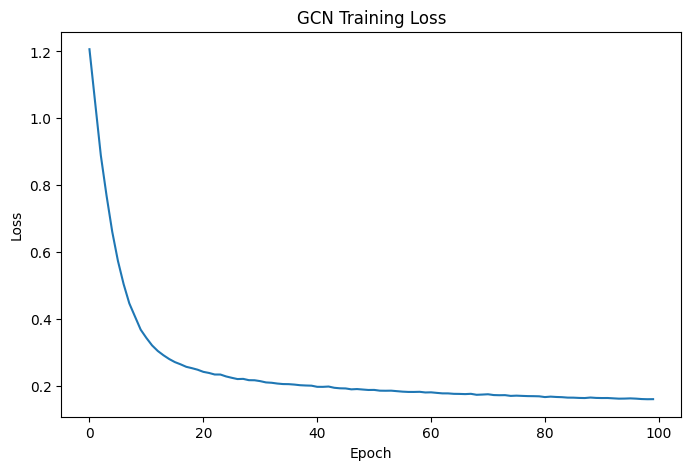

In [23]:
plt.figure(figsize=(8,5))

plt.plot(gcn_losses)

plt.title(
    "GCN Training Loss"
)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.show()

In [24]:
gcn_true,\
gcn_pred,\
gcn_prob = evaluate_model(
    gcn,
    graph_data,
    "GCN"
)


 GCN
              precision    recall  f1-score   support

           0       0.96      0.99      0.98      8404
           1       0.89      0.64      0.75       909

    accuracy                           0.96      9313
   macro avg       0.93      0.82      0.86      9313
weighted avg       0.96      0.96      0.95      9313



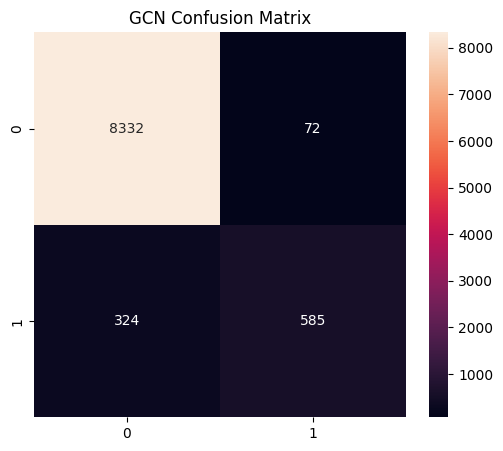

In [25]:
cm=confusion_matrix(
    gcn_true,
    gcn_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title(
    "GCN Confusion Matrix"
)

plt.show()

In [26]:
class GAT(torch.nn.Module):

    def __init__(
            self,
            in_channels):

        super().__init__()

        self.gat1=GATConv(
            in_channels,
            64,
            heads=4
        )

        self.gat2=GATConv(
            64*4,
            2,
            heads=1
        )

    def forward(
            self,
            x,
            edge_index):

        x=self.gat1(
            x,
            edge_index
        )

        x=F.elu(x)

        x=F.dropout(
            x,
            p=0.3,
            training=self.training
        )

        x=self.gat2(
            x,
            edge_index
        )

        return x

In [27]:
gat=GAT(
    graph_data.num_features
)

gat_losses=train_gnn(
    gat,
    graph_data,
    epochs=100
)

Epoch 0 Loss 0.9432
Epoch 10 Loss 0.3255
Epoch 20 Loss 0.2305
Epoch 30 Loss 0.2028
Epoch 40 Loss 0.1910
Epoch 50 Loss 0.1826
Epoch 60 Loss 0.1749
Epoch 70 Loss 0.1697
Epoch 80 Loss 0.1629
Epoch 90 Loss 0.1596


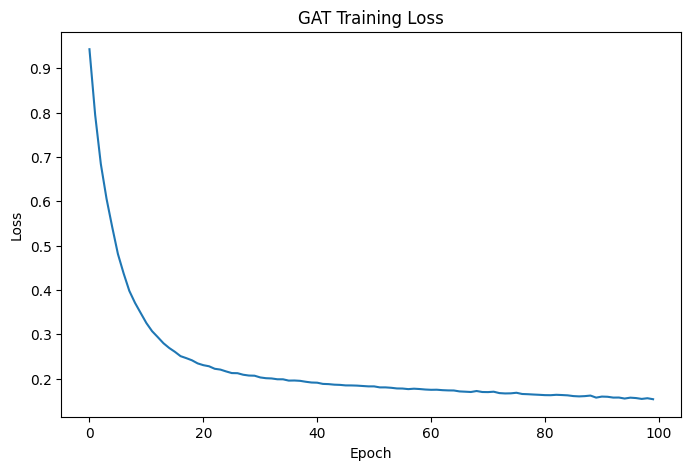

In [28]:
plt.figure(figsize=(8,5))

plt.plot(gat_losses)

plt.title(
    "GAT Training Loss"
)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.show()

In [29]:
gat_true,\
gat_pred,\
gat_prob=evaluate_model(
    gat,
    graph_data,
    "GAT"
)


 GAT
              precision    recall  f1-score   support

           0       0.96      0.99      0.98      8404
           1       0.88      0.66      0.75       909

    accuracy                           0.96      9313
   macro avg       0.92      0.82      0.86      9313
weighted avg       0.96      0.96      0.95      9313



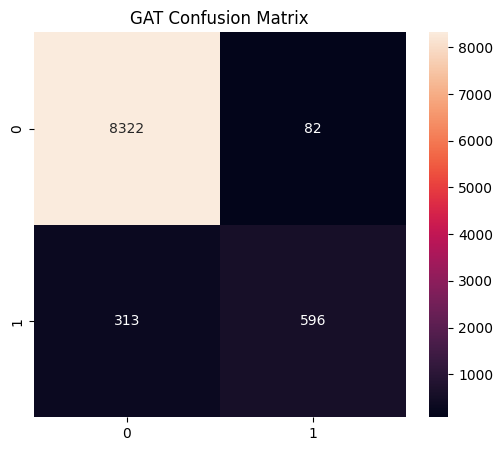

In [30]:
cm=confusion_matrix(
    gat_true,
    gat_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title(
    "GAT Confusion Matrix"
)

plt.show()

In [31]:
class GraphSAGE(torch.nn.Module):

    def __init__(
            self,
            in_channels):

        super().__init__()

        self.sage1=SAGEConv(
            in_channels,
            128
        )

        self.sage2=SAGEConv(
            128,
            2
        )

    def forward(
            self,
            x,
            edge_index):

        x=self.sage1(
            x,
            edge_index
        )

        x=F.relu(x)

        x=F.dropout(
            x,
            p=0.3,
            training=self.training
        )

        x=self.sage2(
            x,
            edge_index
        )

        return x

In [32]:
sage=GraphSAGE(
    graph_data.num_features
)

sage_losses=train_gnn(
    sage,
    graph_data,
    epochs=100
)

Epoch 0 Loss 0.7044
Epoch 10 Loss 0.3058
Epoch 20 Loss 0.2300
Epoch 30 Loss 0.1957
Epoch 40 Loss 0.1738
Epoch 50 Loss 0.1594
Epoch 60 Loss 0.1481
Epoch 70 Loss 0.1390
Epoch 80 Loss 0.1312
Epoch 90 Loss 0.1251


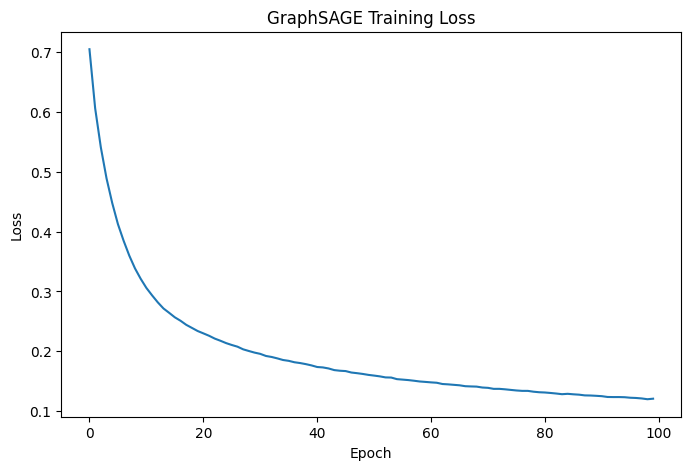

In [33]:
plt.figure(figsize=(8,5))

plt.plot(sage_losses)

plt.title(
    "GraphSAGE Training Loss"
)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.show()

In [34]:
sage_true,\
sage_pred,\
sage_prob=evaluate_model(
    sage,
    graph_data,
    "GraphSAGE"
)


 GraphSAGE
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      8404
           1       0.91      0.72      0.81       909

    accuracy                           0.97      9313
   macro avg       0.94      0.86      0.89      9313
weighted avg       0.96      0.97      0.96      9313



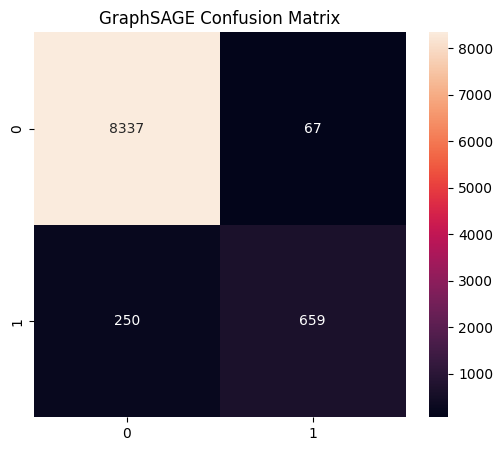

In [35]:
cm=confusion_matrix(
    sage_true,
    sage_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title(
    "GraphSAGE Confusion Matrix"
)

plt.show()

In [36]:
gnn_outputs={

    "GCN":{
        "true":gcn_true,
        "pred":gcn_pred,
        "prob":gcn_prob
    },

    "GAT":{
        "true":gat_true,
        "pred":gat_pred,
        "prob":gat_prob
    },

    "GraphSAGE":{
        "true":sage_true,
        "pred":sage_pred,
        "prob":sage_prob
    }
}

In [37]:
gnn_results=pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC_AUC",
        "PR_AUC"
    ]
)

gnn_results

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,GCN,0.957479,0.890411,0.643564,0.747126,0.942823,0.807120
1,GAT,0.957586,0.879056,0.655666,0.751103,0.946496,0.803412
2,GraphSAGE,0.965962,0.907713,0.724972,0.806116,0.959773,0.861959


In [38]:
gnn_results.to_csv(
    f"{BASE_PATH}/gnn_results.csv",
    index=False
)

print("Saved")

Saved


In [39]:
X_train = X[train_idx]
X_test  = X[test_idx]

y_train = y[train_idx]
y_test  = y[test_idx]

print(X_train.shape)
print(X_test.shape)

(37251, 166)
(9313, 166)


In [40]:
lr = LogisticRegression(
    max_iter=500,
    n_jobs=-1
)

lr.fit(
    X_train,
    y_train
)

LogisticRegression(max_iter=500, n_jobs=-1)

In [41]:
lr_pred = lr.predict(X_test)

lr_prob = lr.predict_proba(X_test)[:,1]

acc = accuracy_score(y_test,lr_pred)

prec = precision_score(y_test,lr_pred)

rec = recall_score(y_test,lr_pred)

f1 = f1_score(y_test,lr_pred)

roc = roc_auc_score(y_test,lr_prob)

pr = average_precision_score(
    y_test,
    lr_prob
)

results.append([
    "Logistic Regression",
    acc,
    prec,
    rec,
    f1,
    roc,
    pr
])

print(classification_report(
    y_test,
    lr_pred
))

              precision    recall  f1-score   support

           0       0.97      0.98      0.98      8404
           1       0.83      0.72      0.77       909

    accuracy                           0.96      9313
   macro avg       0.90      0.85      0.87      9313
weighted avg       0.96      0.96      0.96      9313



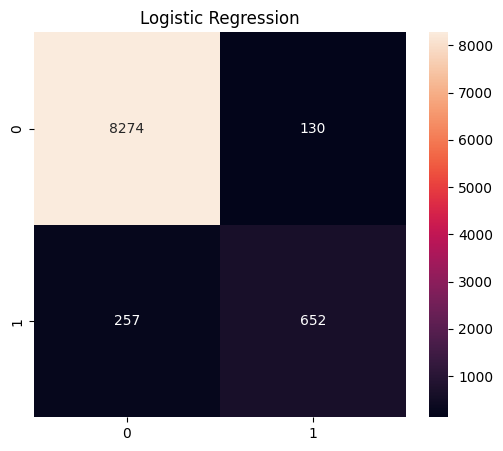

In [42]:
cm = confusion_matrix(
    y_test,
    lr_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title(
    "Logistic Regression"
)

plt.show()

In [43]:
iso = IsolationForest(
    contamination=0.02,
    random_state=42,
    n_estimators=200
)

iso.fit(X_train)

IsolationForest(contamination=0.02, n_estimators=200, random_state=42)

In [44]:
iso_pred = iso.predict(X_test)

iso_pred = np.where(
    iso_pred==-1,
    1,
    0
)

iso_score = -iso.score_samples(
    X_test
)

In [45]:
acc = accuracy_score(
    y_test,
    iso_pred
)

prec = precision_score(
    y_test,
    iso_pred,
    zero_division=0
)

rec = recall_score(
    y_test,
    iso_pred,
    zero_division=0
)

f1 = f1_score(
    y_test,
    iso_pred,
    zero_division=0
)

roc = roc_auc_score(
    y_test,
    iso_score
)

pr = average_precision_score(
    y_test,
    iso_score
)

results.append([
    "Isolation Forest",
    acc,
    prec,
    rec,
    f1,
    roc,
    pr
])

print(classification_report(
    y_test,
    iso_pred
))

              precision    recall  f1-score   support

           0       0.90      0.98      0.94      8404
           1       0.00      0.00      0.00       909

    accuracy                           0.88      9313
   macro avg       0.45      0.49      0.47      9313
weighted avg       0.81      0.88      0.85      9313



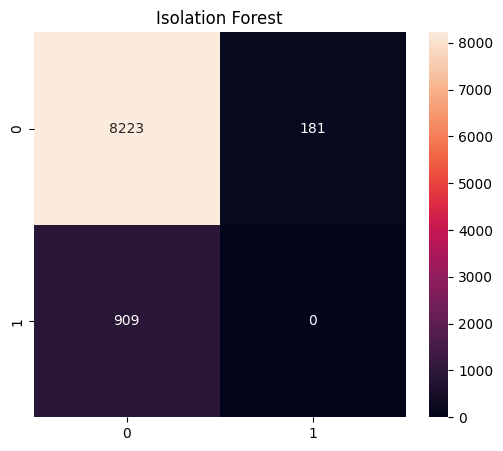

In [46]:
cm = confusion_matrix(
    y_test,
    iso_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title(
    "Isolation Forest"
)

plt.show()

In [47]:
input_dim = X_train.shape[1]

autoencoder = Sequential([

    Dense(
        128,
        activation='relu',
        input_shape=(input_dim,)
    ),

    Dense(
        64,
        activation='relu'
    ),

    Dense(
        32,
        activation='relu'
    ),

    Dense(
        64,
        activation='relu'
    ),

    Dense(
        128,
        activation='relu'
    ),

    Dense(
        input_dim,
        activation='linear'
    )
])

autoencoder.compile(
    optimizer='adam',
    loss='mse'
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [48]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = autoencoder.fit(
    X_train,
    X_train,
    epochs=50,
    batch_size=512,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 6s 31ms/step - loss: 0.8303 - val_loss: 0.5542
Epoch 2/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.5349 - val_loss: 0.3789
Epoch 3/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.3936 - val_loss: 0.2949
Epoch 4/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.3215 - val_loss: 0.2564
Epoch 5/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2776 - val_loss: 0.2350
Epoch 6/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2565 - val_loss: 0.2191
Epoch 7/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2289 - val_loss: 0.2128
Epoch 8/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2089 - val_loss: 0.1991
Epoch 9/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2057 - val_loss: 0.1892
Epoch 10/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1961 - val_loss: 0.1975
Epoch 11/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1818 - val_loss: 0.1701
Epoch 12/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1666 - val_l

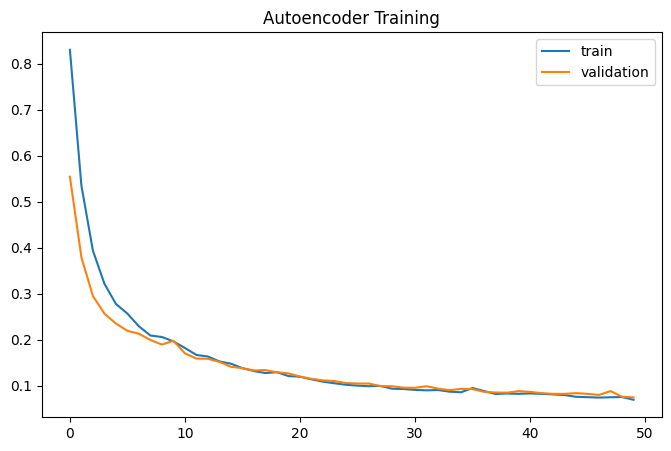

In [49]:
plt.figure(figsize=(8,5))

plt.plot(
    history.history['loss'],
    label='train'
)

plt.plot(
    history.history['val_loss'],
    label='validation'
)

plt.legend()

plt.title(
    "Autoencoder Training"
)

plt.show()

In [50]:
recon = autoencoder.predict(
    X_test
)

mse = np.mean(
    np.square(
        X_test-recon
    ),
    axis=1
)

292/292 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


In [51]:
threshold = np.percentile(
    mse,
    95
)

ae_pred = (
    mse > threshold
).astype(int)

In [52]:
acc = accuracy_score(
    y_test,
    ae_pred
)

prec = precision_score(
    y_test,
    ae_pred,
    zero_division=0
)

rec = recall_score(
    y_test,
    ae_pred,
    zero_division=0
)

f1 = f1_score(
    y_test,
    ae_pred,
    zero_division=0
)

roc = roc_auc_score(
    y_test,
    mse
)

pr = average_precision_score(
    y_test,
    mse
)

results.append([
    "Autoencoder",
    acc,
    prec,
    rec,
    f1,
    roc,
    pr
])

print(classification_report(
    y_test,
    ae_pred
))

              precision    recall  f1-score   support

           0       0.90      0.95      0.92      8404
           1       0.02      0.01      0.01       909

    accuracy                           0.85      9313
   macro avg       0.46      0.48      0.47      9313
weighted avg       0.81      0.85      0.83      9313



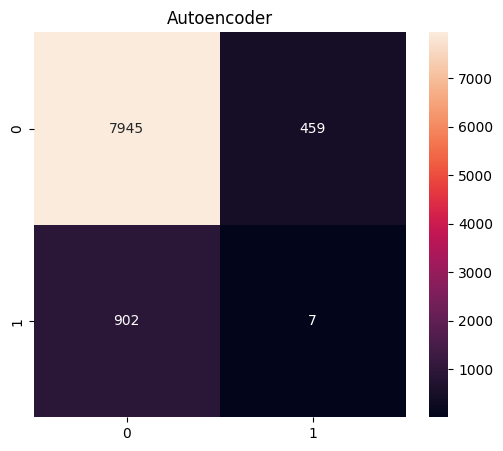

In [53]:
cm = confusion_matrix(
    y_test,
    ae_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title(
    "Autoencoder"
)

plt.show()

In [54]:
final_results = pd.DataFrame(

    results,

    columns=[

        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC_AUC",
        "PR_AUC"
    ]
)

final_results.sort_values(
    by="F1",
    ascending=False,
    inplace=True
)

final_results

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
2,GraphSAGE,0.965962,0.907713,0.724972,0.806116,0.959773,0.861959
3,Logistic Regression,0.958445,0.833760,0.717272,0.771141,0.964126,0.792861
1,GAT,0.957586,0.879056,0.655666,0.751103,0.946496,0.803412
0,GCN,0.957479,0.890411,0.643564,0.747126,0.942823,0.807120
5,Autoencoder,0.853860,0.015021,0.007701,0.010182,0.175486,0.055937
4,Isolation Forest,0.882959,0.000000,0.000000,0.000000,0.102338,0.052351


In [55]:
final_results.to_csv(

    f"{BASE_PATH}/Final_Model_Results.csv",

    index=False
)

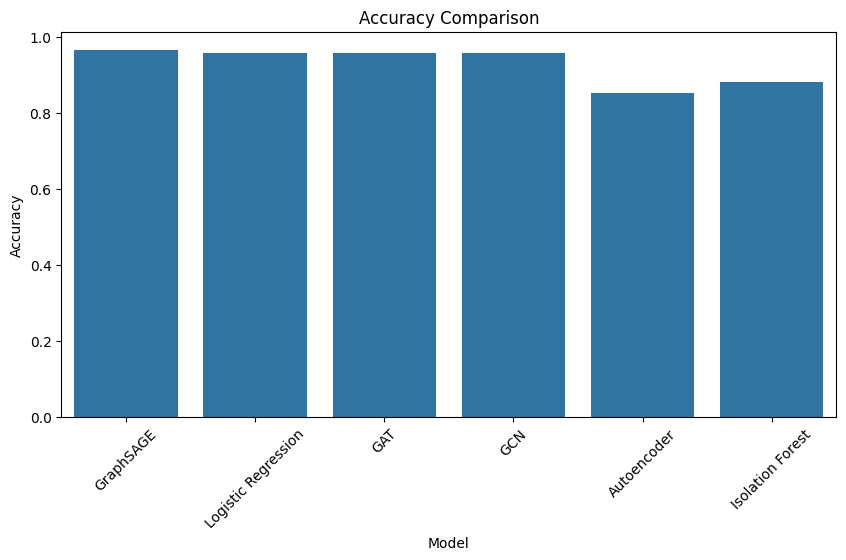

In [56]:
plt.figure(figsize=(10,5))

sns.barplot(

    x="Model",

    y="Accuracy",

    data=final_results
)

plt.xticks(rotation=45)

plt.title(
    "Accuracy Comparison"
)

plt.show()

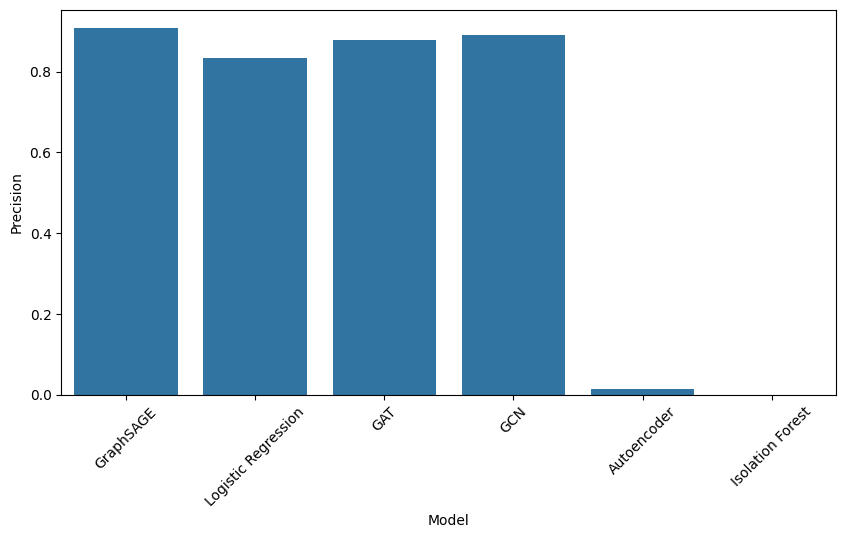

In [57]:
plt.figure(figsize=(10,5))

sns.barplot(

    x="Model",

    y="Precision",

    data=final_results
)

plt.xticks(rotation=45)

plt.show()

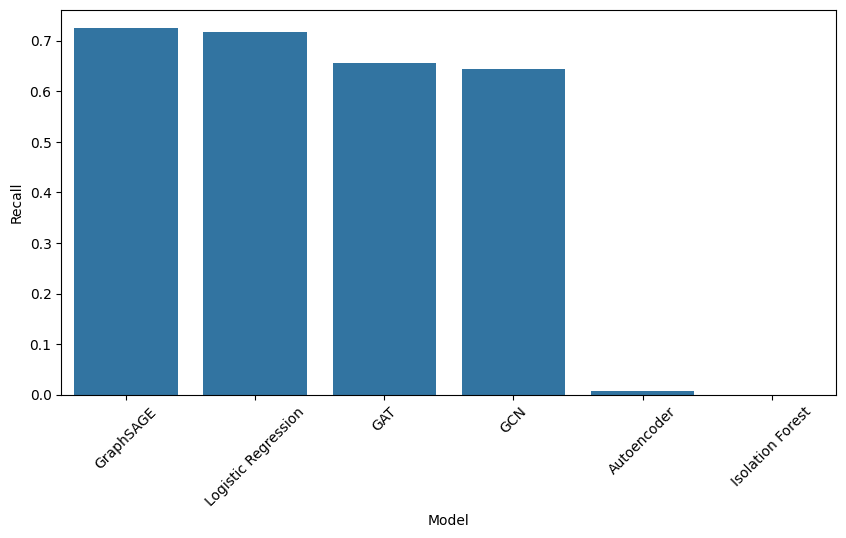

In [58]:
plt.figure(figsize=(10,5))

sns.barplot(

    x="Model",

    y="Recall",

    data=final_results
)

plt.xticks(rotation=45)

plt.show()

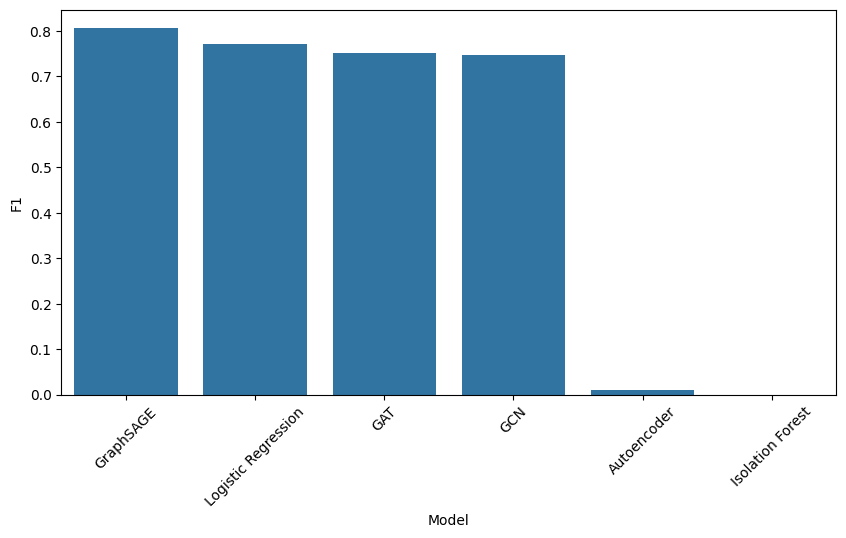

In [59]:
plt.figure(figsize=(10,5))

sns.barplot(

    x="Model",

    y="F1",

    data=final_results
)

plt.xticks(rotation=45)

plt.show()

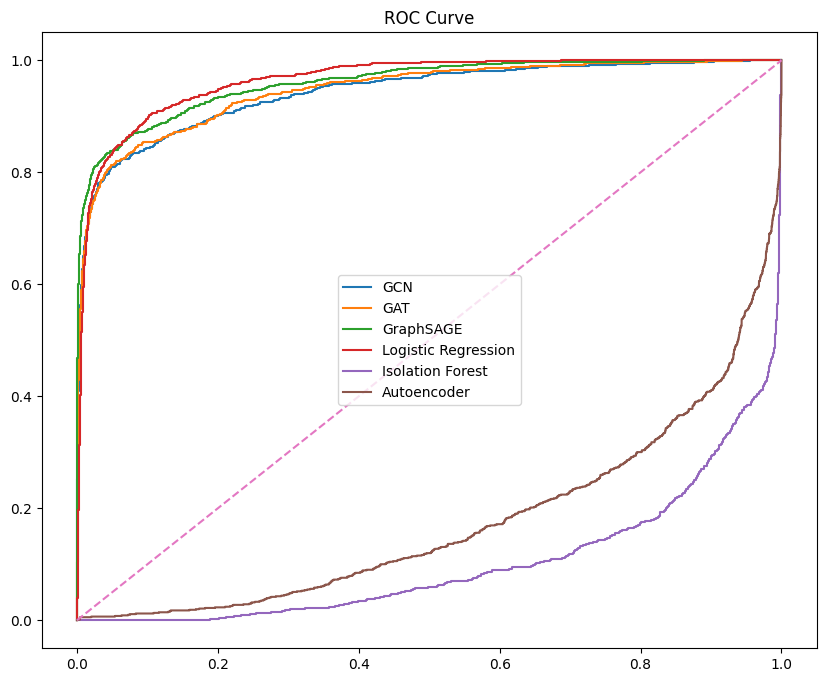

In [60]:
plt.figure(figsize=(10,8))

for name,obj in gnn_outputs.items():

    fpr,tpr,_ = roc_curve(
        obj["true"],
        obj["prob"]
    )

    plt.plot(
        fpr,
        tpr,
        label=name
    )

fpr,tpr,_ = roc_curve(
    y_test,
    lr_prob
)

plt.plot(
    fpr,
    tpr,
    label="Logistic Regression"
)

fpr,tpr,_ = roc_curve(
    y_test,
    iso_score
)

plt.plot(
    fpr,
    tpr,
    label="Isolation Forest"
)

fpr,tpr,_ = roc_curve(
    y_test,
    mse
)

plt.plot(
    fpr,
    tpr,
    label="Autoencoder"
)

plt.plot(
    [0,1],
    [0,1],
    '--'
)

plt.legend()

plt.title("ROC Curve")

plt.show()

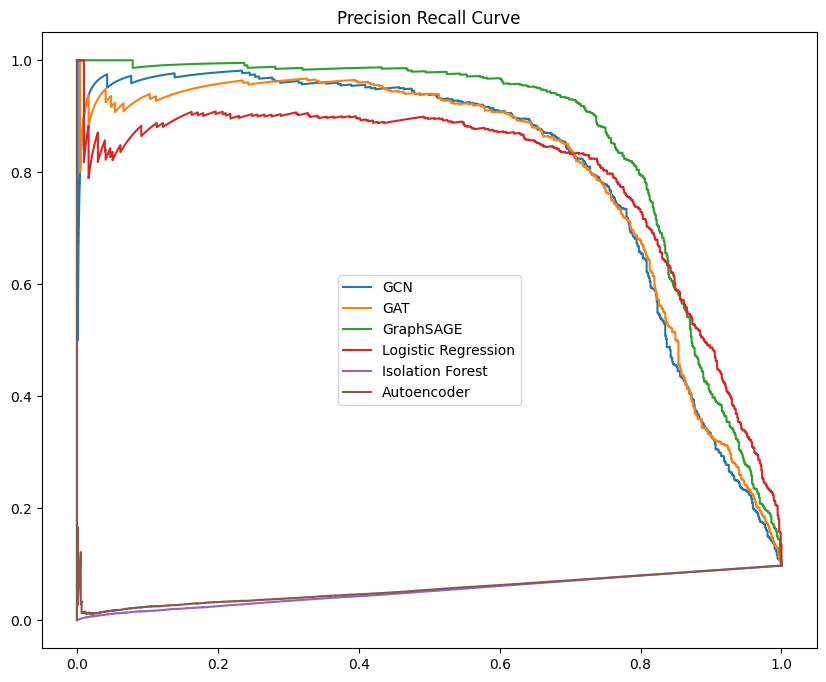

In [61]:
plt.figure(figsize=(10,8))

for name,obj in gnn_outputs.items():

    p,r,_ = precision_recall_curve(
        obj["true"],
        obj["prob"]
    )

    plt.plot(
        r,
        p,
        label=name
    )

p,r,_ = precision_recall_curve(
    y_test,
    lr_prob
)

plt.plot(
    r,
    p,
    label="Logistic Regression"
)

p,r,_ = precision_recall_curve(
    y_test,
    iso_score
)

plt.plot(
    r,
    p,
    label="Isolation Forest"
)

p,r,_ = precision_recall_curve(
    y_test,
    mse
)

plt.plot(
    r,
    p,
    label="Autoencoder"
)

plt.legend()

plt.title(
    "Precision Recall Curve"
)

plt.show()

In [62]:
ranking = final_results.sort_values(
    by="F1",
    ascending=False
)

ranking

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
2,GraphSAGE,0.965962,0.907713,0.724972,0.806116,0.959773,0.861959
3,Logistic Regression,0.958445,0.833760,0.717272,0.771141,0.964126,0.792861
1,GAT,0.957586,0.879056,0.655666,0.751103,0.946496,0.803412
0,GCN,0.957479,0.890411,0.643564,0.747126,0.942823,0.807120
5,Autoencoder,0.853860,0.015021,0.007701,0.010182,0.175486,0.055937
4,Isolation Forest,0.882959,0.000000,0.000000,0.000000,0.102338,0.052351


In [63]:
best_model = ranking.iloc[0]

print(
    best_model
)

Model        GraphSAGE
Accuracy      0.965962
Precision     0.907713
Recall        0.724972
F1            0.806116
ROC_AUC       0.959773
PR_AUC        0.861959
Name: 2, dtype: object


In [64]:
with pd.ExcelWriter(

    f"{BASE_PATH}/Dissertation_Results.xlsx"

) as writer:

    final_results.to_excel(
        writer,
        sheet_name="Model Results",
        index=False
    )

print("Export Complete")

Export Complete


In [65]:
chapter4_table = final_results.copy()

chapter4_table.round(4)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
2,GraphSAGE,0.9660,0.9077,0.7250,0.8061,0.9598,0.8620
3,Logistic Regression,0.9584,0.8338,0.7173,0.7711,0.9641,0.7929
1,GAT,0.9576,0.8791,0.6557,0.7511,0.9465,0.8034
0,GCN,0.9575,0.8904,0.6436,0.7471,0.9428,0.8071
5,Autoencoder,0.8539,0.0150,0.0077,0.0102,0.1755,0.0559
4,Isolation Forest,0.8830,0.0000,0.0000,0.0000,0.1023,0.0524
